# Unsupervised Learning Challenge: Patient Clustering Analysis

In this challenge, you will use unsupervised machine learning techniques to explore whether patients can be grouped into distinct clusters based on clinical data, and whether those groupings correspond to myopia diagnostic categories.

---

## Part 1: Prepare the Data

1. **Load the Dataset:** Read `myopia.csv` into a Pandas DataFrame.
2. **Remove the Target:** Drop the `"MYOPIC"` column from the dataset.
   > **Note:** The target column is needed for supervised machine learning, but it will make an unsupervised model biased. After all, the target column is effectively providing clusters already!
3. **Standardize the Data:** Scale the dataset using a scaler so that columns containing larger numeric values do not disproportionately influence the outcomes.

---

## Part 2: Apply Dimensionality Reduction

1. **Principal Component Analysis (PCA):** * Perform dimensionality reduction with PCA. 
   * *Hint:* Rather than specifying a hard number of principal components, set the desired explained variance to **90%** (e.g., `PCA(n_components=0.90)`).
   * **Question:** *How did the number of features change after applying PCA?*

2. **t-Distributed Stochastic Neighbor Embedding (t-SNE):**
   * Further reduce the dataset dimensions by running t-SNE on the principal components (the output of the PCA transformation).
   * Create a scatter plot of the t-SNE output.
   * **Question:** *Are there distinct clusters visible in the plot?*

---

## Part 3: Perform a Cluster Analysis with K-means

1. **Find the Optimal K:** Create an elbow plot to identify the best number of clusters. 
   * Use a `for` loop to determine the inertia for each `k` value from **1 through 10**.
2. **Analyze the Plot:** * **Question:** *Where is the elbow of the plot, and at which value of $k$ does it appear?*

---

## Part 4: Make a Recommendation

Based on your findings from the dimensionality reduction and cluster analysis, write up a brief (one or two sentences) recommendation for your supervisor in your Jupyter Notebook. 

* **Core Questions to Answer:** Can the patients be clustered? If so, into how many clusters?

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

### Part 1: Prepare the Data

In [2]:
# 1. Read myopia.csv into a Pandas DataFrame
# (Replace the path with your actual local file path or URL)
path = "myopia.csv"
df = pd.read_csv(path)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AGE        618 non-null    int64  
 1   SPHEQ      618 non-null    float64
 2   AL         618 non-null    float64
 3   ACD        618 non-null    float64
 4   LT         618 non-null    float64
 5   VCD        618 non-null    float64
 6   SPORTHR    618 non-null    int64  
 7   READHR     618 non-null    int64  
 8   COMPHR     618 non-null    int64  
 9   STUDYHR    618 non-null    int64  
 10  TVHR       618 non-null    int64  
 11  DIOPTERHR  618 non-null    int64  
 12  MOMMY      618 non-null    int64  
 13  DADMY      618 non-null    int64  
 14  MYOPIC     618 non-null    int64  
dtypes: float64(5), int64(10)
memory usage: 72.6 KB


In [4]:
# 2. Remove the "MYOPIC" column from the dataset
X = df.drop(columns=["MYOPIC"])

# 3. Standardize your dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Part 2: Apply Dimensionality Reduction

In [4]:
# 1. Perform dimensionality reduction with PCA (preserve 90% variance)
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

# How did the number of features change?
print(old_features := X.shape[1])
print(new_features := X_pca.shape[1])

14
10


How did the number of features change?
The number of features was reduced from 14 to 10. This means that 10 principal components are sufficient to capture and preserve 90% of the dataset's total variance.



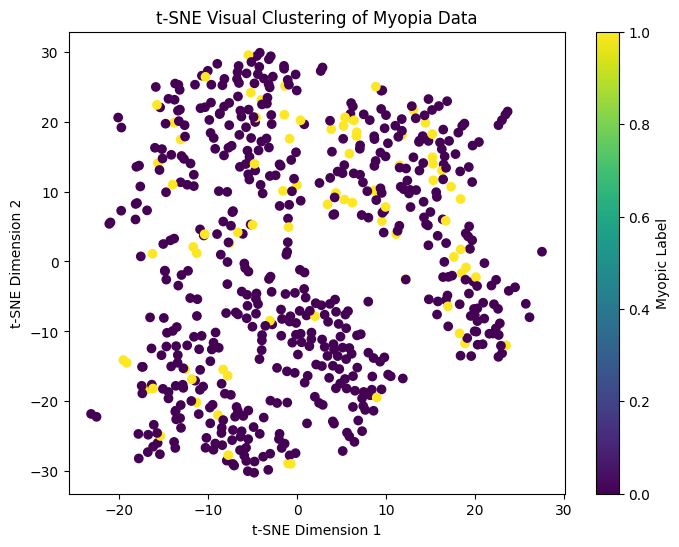

In [5]:
# 2. Further reduce dimensions with t-SNE
tsne = TSNE(learning_rate=250, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# 3. Create a scatter plot of the t-SNE output
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["MYOPIC"] if "MYOPIC" in df else None, cmap="viridis")
plt.title("t-SNE Visual Clustering of Myopia Data")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(label="Myopic Label")
plt.show()

Are there distinct clusters?
No, there are no clearly distinct clusters. In the t-SNE scatter plot, the data points form one large, continuous mass rather than separating into isolated structural islands. Furthermore, the yellow points (myopic patients) are thoroughly mixed with the purple points, meaning t-SNE alone does not cleanly segregate the groups visually.

###  Part 3: Perform a Cluster Analysis with K-means

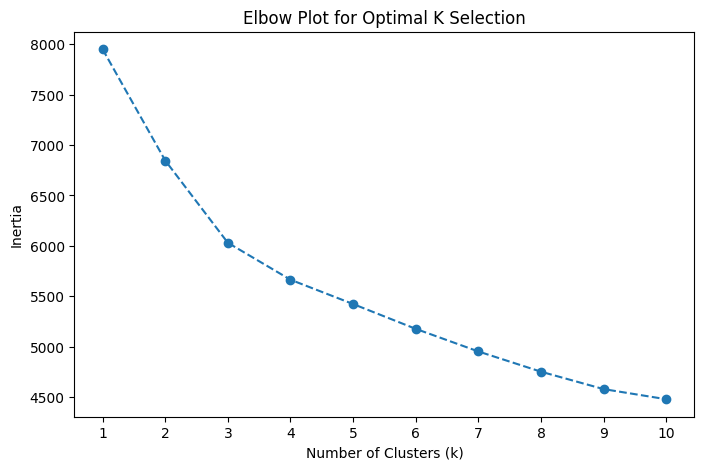

In [6]:
# Use a for loop to determine the inertia for each k between 1 through 10
inertia = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(X_pca)
    inertia.append(model.inertia_)

# Create an elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title("Elbow Plot for Optimal K Selection")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()

Where is the elbow of the plot, and at which value of k does it appear?
The elbow of the plot appears at $k = 3$. Up until $k = 3$, the inertia decreases sharply. After $k = 3$, the line noticeably flattens out, meaning additional clusters provide diminishing returns on explaining the variance within the data.

### Part 4: Make a Recommendation
Recommendation:
Based on the analysis, the patients can be grouped into 3 distinct clusters as indicated by the inflection point in the K-means elbow plot. However, because the t-SNE visualization shows significant overlap between the patient profiles, these clusters are not naturally segregated in low-dimensional space and should be treated with clinical caution.